In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

In [ ]:
# 1. Load the dataset
print("Loading Disease X Dataset...")
df = pd.read_csv('/content/covid_symptoms_severity_prediction.csv')
df.head()

Loading Disease X Dataset...


,age,gender,vaccination_status,fever,cough,fatigue,shortness_of_breath,loss_of_smell,headache,diabetes,hypertension,heart_disease,asthma,cancer,hospitalized,icu_admission,mortality
0,51,Male,Unvaccinated,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,92,Male,Fully Vaccinated,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,14,Male,Fully Vaccinated,0,1,0,0,0,0,0,0,0,0,1,0,0,0
3,71,Male,Fully Vaccinated,1,1,0,0,0,0,0,1,0,0,0,0,0,0
4,60,Male,Unvaccinated,0,1,1,1,1,0,1,1,1,0,0,1,1,0


In [ ]:
# Check for null values in the dataset
print("Checking for null values:")
print(df.isna().sum())

Checking for null values:
age                    0
gender                 0
vaccination_status     0
fever                  0
cough                  0
fatigue                0
shortness_of_breath    0
loss_of_smell          0
headache               0
diabetes               0
hypertension           0
heart_disease          0
asthma                 0
cancer                 0
hospitalized           0
icu_admission          0
mortality              0
dtype: int64


In [ ]:
# 2. Preprocessing: Drop outcome columns and define target variable
X = df.drop(columns=['vaccination_status', 'icu_admission', 'hospitalized', 'mortality'])
y = df['icu_admission']

In [ ]:
# 3. Convert 'gender' column from text to numerical format using one-hot encoding
X = pd.get_dummies(X, columns=['gender'], drop_first=True)

In [ ]:
# 4. Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

icu_admission
0    2727
1     273
Name: count, dtype: int64
icu_admission
0    90.9
1     9.1
Name: proportion, dtype: float64


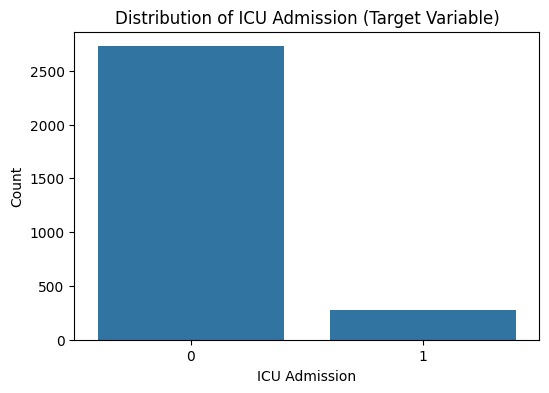

In [ ]:
# Visualize the distribution of the target variable
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of ICU Admission (Target Variable)')
plt.xlabel('ICU Admission')
plt.ylabel('Count')
plt.show()

In [ ]:
# 5. Applying SMOTE to balance the dataset (Resampling)
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}")
print("\nNew Target Distribution:")
print(y_train_res.value_counts())

Original training shape: (2400, 14)
Resampled training shape: (4380, 14)

New Target Distribution:
icu_admission
0    2190
1    2190
Name: count, dtype: int64


In [ ]:
# 6. Model Evaluation with CLASS WEIGHTS (The SMOTE Fix)
print("--- Model Evaluation with CLASS WEIGHTS (The SMOTE Fix) ---")
best_model_cw = None
best_f1_cw = 0
best_name_cw = ""

# Calculate the exact weight ratio for XGBoost (Majority Class / Minority Class)
# Assuming 90% vs 10%, the weight is roughly 9 or 10. We will use 10.
xgb_weight = 10

# Define models with algorithmic penalties instead of fake data
models_cw = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='logloss', scale_pos_weight=xgb_weight),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
}

# CRITICAL FIX: Train on the ORIGINAL data (X_train, y_train), NOT the SMOTE data (X_train_res)
for name, model in models_cw.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

    if f1 > best_f1_cw:
        best_f1_cw = f1
        best_name_cw = name
        best_model_cw = model

print("-" * 30)
print(f"WINNER with CLASS WEIGHTS: {best_name_cw} ({best_f1_cw:.4f})")

--- Model Evaluation with CLASS WEIGHTS (The SMOTE Fix) ---
Logistic Regression: Accuracy = 0.7317, F1-Score = 0.3735
Random Forest: Accuracy = 0.8833, F1-Score = 0.1463
XGBoost: Accuracy = 0.8267, F1-Score = 0.3158
SVM: Accuracy = 0.6033, F1-Score = 0.2699
------------------------------
WINNER with CLASS WEIGHTS: Logistic Regression (0.3735)


Evaluating Model: Logistic Regression
False Alarm Rate: 27.19%


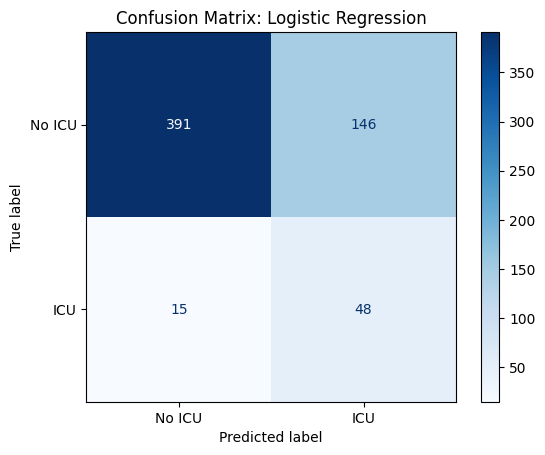

In [ ]:
# Visualize model performance with a Confusion Matrix (Simple Evaluation: Class Weights vs Baseline)
target_model = best_model_cw if 'best_model_cw' in locals() else None
target_name = best_name_cw if 'best_name_cw' in locals() else 'Baseline'

if target_model is not None:
    # Calculate and Plot
    final_preds = target_model.predict(X_test)
    cm = confusion_matrix(y_test, final_preds)
    fa_rate = cm[0, 1] / (cm[0, 0] + cm[0, 1])

    print(f"Evaluating Model: {target_name}")
    print(f"False Alarm Rate: {fa_rate:.2%}")

    ConfusionMatrixDisplay.from_predictions(y_test, final_preds, display_labels=['No ICU', 'ICU'], cmap='Blues')
    plt.title(f'Confusion Matrix: {target_name}')
    plt.show()
else:
    print("Error: No trained model found. Please run the training cell (80f47d3e) first.")

In [ ]:
# Display a detailed classification report for the winning model
print(f"\nDetailed Report for ACTUAL WINNER: {best_name_cw}")
print(classification_report(y_test, best_model_cw.predict(X_test)))


Detailed Report for ACTUAL WINNER: Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.73      0.83       537
           1       0.25      0.76      0.37        63

    accuracy                           0.73       600
   macro avg       0.61      0.75      0.60       600
weighted avg       0.89      0.73      0.78       600



In [ ]:
# 7. Save the Winning Model Checkpoint
# Saving the model that performed best during evaluation
model_data = {
    'model': best_model_cw,
    'features': X.columns.tolist(),
    'method': 'Class Weights'
}

joblib.dump(model_data, 'disease_x_vulnerability_v1.pkl')
print(f"Winning model ({best_name_cw}) saved successfully as 'disease_x_vulnerability_v1.pkl'!")

Winning model (Logistic Regression) saved successfully as 'disease_x_vulnerability_v1.pkl'!
